In [2]:
#%%
"""
sweep_santec_pm320e.py
Created on 2026-02-26
Author: Jan Scarabelli Calopa

New version of Lab_Codes/wavelength_sweep_santec.py to use 
with PM320E instead of PM100 
"""
import pyvisa
import qontrol
import tqdm
import clr
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ThorlabsPM100 import ThorlabsPM100
from Functions import *

rm = pyvisa.ResourceManager()

In [3]:
#%% Get list of connected devices
resources = rm.list_resources()
print(resources)  # Should list something like 'USB0::0x1313::0x8022::M00606447::INSTR', ...

('USB0::0x1313::0x8022::M00606447::INSTR', 'USB0::0x1313::0x8048::M00245549::INSTR', 'ASRL3::INSTR', 'ASRL11::INSTR', 'ASRL12::INSTR')


In [4]:
#%% Connect to PM320E
pm320e_name = 'USB0::0x1313::0x8022::M00606447::INSTR' # change if different PM
try:
    pm320e = rm.open_resource(pm320e_name)
    pm320e.write('POW2DBM')
    print("PM320E: Connection Successful!")
except Exception as e:
    print(f"PM320E: Connection error - {e}")

#%% Connect to PM100
pm100_name = "USB0::0x1313::0x8078::P0017921::0::INSTR" # PM100
try:
    r_pm100 = rm.open_resource(pm100_name)
    r_pm100.write('CONF:POW')
    pm100 = ThorlabsPM100(inst=r_pm100)
    pm100.timeout = 5000
    pm100.sense.correction.wavelength=1550
    print("PM100: Connection Successful!")

except Exception as e:
    print(f"PM100: Connection error - {e}")

#print(inst.query("*IDN?"))

PM320E: Connection Successful!
PM100: Connection error - VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.


In [9]:
#%% Auxiliary functions
def read_power_mW(pm, channel=None):
    """
    Reads the power from the power meter and converts it to mW.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        p_in_w = pm.query(f":POW{channel}:VAL?")
    except:
        try:
            # PM100
            p_in_w = pm.read
        except:
            raise ValueError("Could not read power from the power meter")

    
    p_in_mw = float(p_in_w) * 1e3  # Convert W to mW
    return p_in_mw

def read_power_dbm(pm, channel=None):
    """
    Reads the power from the power meter and converts it to dBm.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        p_in_w = pm.query(f":POW{channel}:VAL?")
    except:
        try:
            # PM100
            p_in_w = pm.read
        except:
            raise ValueError("Could not read power from the power meter")

    
    p_in_dbm = 10 * np.log10(float(p_in_w) * 1e3)  # Convert W to mW and then to dBm
    return p_in_dbm

def set_measuring_wavelength(pm, wavelength, channel=None):
    """
    Sets the measuring wavelength for the power meter.
    Tries for both PM320E and PM100 formats.
    """
    try:
        # PM320E
        pm.write(f":WAVEL{channel}:VAL {wavelength}")  # Set wavelength for channel 1
    except:
        try:
            # PM100
            pm.sense.correction.wavelength = wavelength
        except:
            raise ValueError("Could not set measuring wavelength")
        


In [ ]:
#%% Try to read power

try:
    p1_dbm = read_power_dbm(pm=pm320e, channel=1)
    print(f"PM320E Power in dBm: {p1_dbm}")
except Exception as e:
    print(f"Error reading PM320E power: {e}")

try:
    p2_dbm = read_power_dbm(pm=pm320e, channel=2)
    print(f"PM320E Power in dBm: {p2_dbm}")
except Exception as e:
    print(f"Error reading PM320E power: {e}")

print(f"Measured Power 1 in dBm: {p1_dbm}")
print(f"Measured Power 2 in dBm: {p2_dbm}")

PM320E Power in dBm: -0.9638005152805831
PM320E Power in dBm: -64.39487450969605
Measured Power 1 in dBm: -0.9638005152805831
Measured Power 2 in dBm: -64.39487450969605


In [7]:
#%% Stablish connection with drivers
q = Qontrol(COM=11)
q.reset()  # set all voltages to 0

In [ ]:
#%%Just sweep voltage, no saving data

voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.1)]  # range of voltages to sweep across - extremes included
#voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.5)]  # range of voltages to sweep across - extremes included

heater = 11  # AMZI-1: 12, AMZI-2: 3 (after remapping 27/02/2026)

for v_applied in tqdm.tqdm(voltage_range, desc="Sweeping voltages"):
    q.set_v(heater, v_applied)
    #out_str = f"Voltage: {q.read_v(heater):.4f}, Current: {q.read_i(heater):.4f} || "
    
    time.sleep(0.1)

q.reset()  # set all voltages back to 0 after sweep

In [114]:
q.reset()

In [120]:
#%% Sweep across voltages, save data

fname = "voltage_sweep_mzi1_in20_out22.csv"

voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.1)]  # range of voltages to sweep across - extremes included
#voltage_range = [round(float(i), 3) for i in np.arange(0, 12.1, 0.5)]  # range of voltages to sweep across - extremes included

heater = 10  # AMZI-1: 12, AMZI-2: 3 (after remapping 27/02/2026)
q.reset()  # set all voltages to 0 before sweep

df_voltage_sweep = pd.DataFrame(columns=["V_applied", "V_measured", "I_measured", "P_Op_dBm", "P_Op_mW"])
#df_voltage_sweep = pd.DataFrame(columns=["V_applied", "V_measured", "I_measured", "P_Op_dBm_16", "P_Op_dBm_17"])

df_voltage_sweep = df_voltage_sweep.set_index("V_applied")

for v_applied in tqdm.tqdm(voltage_range, desc="Sweeping voltages"):
    q.set_v(heater, v_applied)
    out_str = f"Voltage: {q.read_v(heater):.4f}, Current: {q.read_i(heater):.4f} || "
    #print(f"\r{out_str}", end="", flush=True)
    
    time.sleep(0.1)

    v_meas = q.read_v(heater)
    i_meas = q.read_i(heater)
    p_op_mw = read_power_mW(pm=pm320e, channel=2)
    
    time.sleep(1)

    df_voltage_sweep.loc[v_applied] = [v_meas, i_meas, p_op_dbm, p_op_mw]

df_voltage_sweep["P_Op_dBm"] = df_voltage_sweep["P_Op_mW"].apply(lambda x: 10 * np.log10(x) if x > 0 else -np.inf)  # Convert mW to dBm, handle zero power case
data_path = r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\MZIs\data"
df_voltage_sweep.to_csv(rf"{data_path}\{fname}")
q.reset()  # set all voltages back to 0 after sweep

Sweeping voltages: 100%|██████████| 121/121 [02:25<00:00,  1.20s/it]


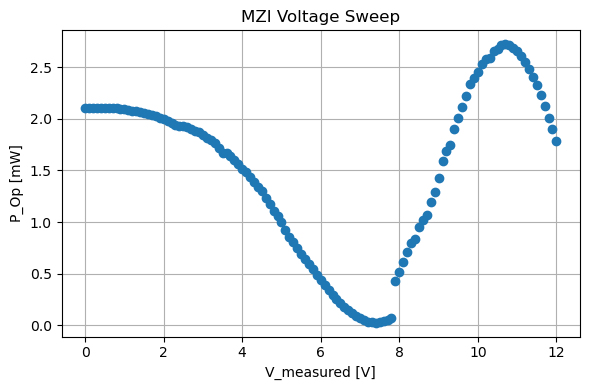

In [121]:
#%% Plot result of voltage sweep
plt.figure(figsize=(6,4))

x = df_voltage_sweep["V_measured"]
y = df_voltage_sweep["P_Op_mW"]

plt.plot(x, y, 'o')

plt.xlabel("V_measured [V]")
plt.ylabel("P_Op [mW]")
plt.title("MZI Voltage Sweep")
plt.tight_layout()
plt.grid()
plt.show()

In [122]:
pi_ps = np.argmin(df_voltage_sweep["P_Op_mW"])
zero_ps = np.argmax(df_voltage_sweep["P_Op_mW"])
print(f"Zero phase shift at V = {df_voltage_sweep.index[zero_ps]:.3f} V, Pi phase shift at V = {df_voltage_sweep.index[pi_ps]:.3f} V")

Zero phase shift at V = 10.700 V, Pi phase shift at V = 7.400 V


In [138]:
q.set_v(heater, 10.7)

In [129]:
q.read_v(heater)

10.6999

In [134]:
def dbm_to_mw(dbm):
    return 10 ** (dbm / 10)

dbm_to_mw(dbm=4)

2.51188643150958

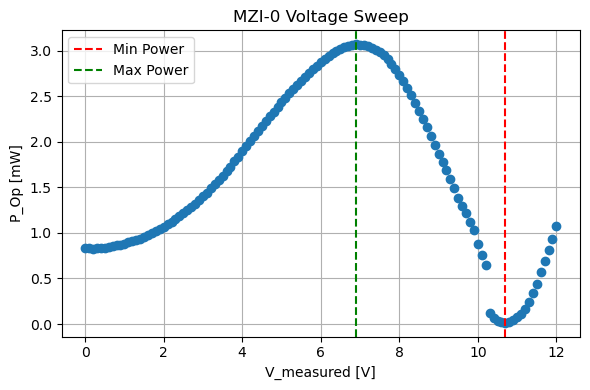

In [118]:
#%% Plot result of voltage sweep
plt.figure(figsize=(6,4))

x = df_voltage_sweep["V_measured"]
y = df_voltage_sweep["P_Op_mW"]

plt.plot(x, y, 'o')

# Find extrema
pi_ps = np.argmin(df_voltage_sweep["P_Op_mW"])
zero_ps = np.argmax(df_voltage_sweep["P_Op_mW"])

pi_v = x.iloc[pi_ps]
zero_v = x.iloc[zero_ps]

# Add dashed vertical lines
plt.axvline(pi_v, color='red', linestyle='--', label='Min Power')
plt.axvline(zero_v, color='green', linestyle='--', label='Max Power')

plt.xlabel("V_measured [V]")
plt.ylabel("P_Op [mW]")
plt.title("MZI-0 Voltage Sweep")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()


In [66]:
mzi0_in23 = pd.read_csv(r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\MZIs\data\voltage_sweep_mzi0_in23_out25.csv", index_col="V_applied")
mzi0_in24 = pd.read_csv(r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\MZIs\data\voltage_sweep_mzi0_in24_out25.csv", index_col="V_applied")

mzi1_in20 = pd.read_csv(r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\MZIs\data\voltage_sweep_mzi1_in20_out22.csv", index_col="V_applied")
mzi1_in21 = pd.read_csv(r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation\MZIs\data\voltage_sweep_mzi1_in21_out22.csv", index_col="V_applied")

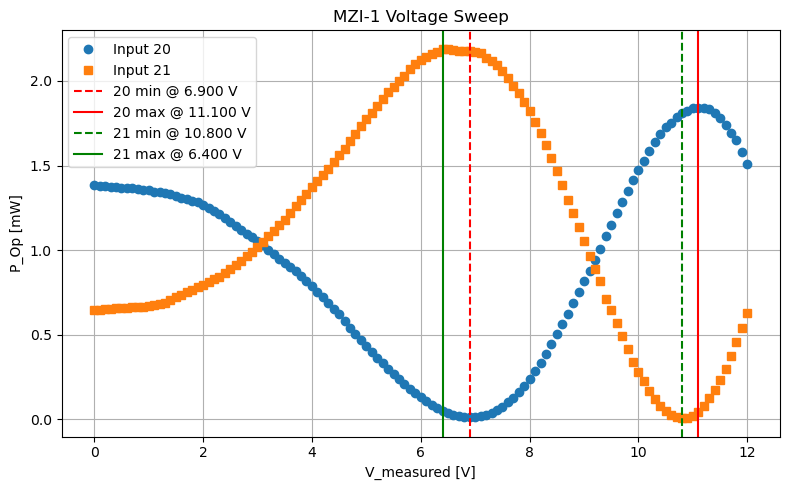

In [71]:
plt.figure(figsize=(8,5))

# Plot the two sweeps
plt.plot(mzi1_in20.index, mzi1_in20["P_Op_mW"], 'o', label="Input 20")
plt.plot(mzi1_in21.index, mzi1_in21["P_Op_mW"], 's', label="Input 21")

# --- Find extrema for Input 23 ---
y1 = mzi1_in20["P_Op_mW"]
x1_min = y1.idxmin()
x1_max = y1.idxmax()

# --- Find extrema for Input 24 ---
y2 = mzi1_in21["P_Op_mW"]
x2_min = y2.idxmin()
x2_max = y2.idxmax()

# --- Draw vertical lines ---
plt.axvline(x1_min, color='red', linestyle='--', label=f"20 min @ {x1_min:.3f} V")
plt.axvline(x1_max, color='red', linestyle='-',  label=f"20 max @ {x1_max:.3f} V")

plt.axvline(x2_min, color='green', linestyle='--', label=f"21 min @ {x2_min:.3f} V")
plt.axvline(x2_max, color='green', linestyle='-',  label=f"21 max @ {x2_max:.3f} V")

# --- Add these x-values to the ticks ---
#xticks = sorted(set(list(plt.xticks()[0]) + 
                    #[x23_min, x23_max, x24_min, x24_max]))
#plt.xticks(xticks)

# Labels and styling
plt.xlabel("V_measured [V]")
plt.ylabel("P_Op [mW]")
plt.title("MZI-1 Voltage Sweep")
plt.grid()
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()


In [107]:
q.reset()

In [110]:
q.set_v(11, 6.4)

coupling in 24 (35mm) - 5.6 dbm
coupling in 23 (45mm) - 5.6 dbm
coupling in 21 (55mm) - 5. dbm


Generation Rate Trend Analysis

In [139]:
data_path = r"C:\Users\FTNK-LocalAdm\OneDrive - Danmarks Tekniske Universitet\Jan Files\Photon Pair Generation"

file_35 = data_path + r"\35mm\data\cohist_35mm_120s_si70ghz_p70ghz_bw2_nb1000.txt"
file_45 = data_path + r"\45mm\data\cohist_45mm_120s_si70ghz_p70ghz_bw2_nb1000.txt"
file_55 = data_path + r"\55mm\data\cohist_55mm_120s_si70ghz_p70ghz_bw2_nb1000.txt"
file_65 = data_path + r"\65mm\data\cohist_65mm_120s_si70ghz_p70ghz_bw2_nb1000.txt"

file_35_trace = data_path + r"\35mm\data\cohist_35mm_120s_si70ghz_p70ghz_bw2_nb1000_trace.txt"
file_45_trace = data_path + r"\45mm\data\cohist_45mm_120s_si70ghz_p70ghz_bw2_nb1000_trace.txt"
file_55_trace = data_path + r"\55mm\data\cohist_55mm_120s_si70ghz_p70ghz_bw2_nb1000_trace.txt"
file_65_trace = data_path + r"\65mm\data\cohist_65mm_120s_si70ghz_p70ghz_bw2_nb1000_trace.txt"

s1_35 = pd.read_csv(file_35, sep = "\t")
s2_45 = pd.read_csv(file_45, sep = "\t")
s3_55 = pd.read_csv(file_55,  sep = "\t")
s4_65 = pd.read_csv(file_65, sep = "\t")

s1_35_trace = pd.read_csv(file_35_trace, sep = "\t")
s2_45_trace = pd.read_csv(file_45_trace, sep = "\t")
s3_55_trace = pd.read_csv(file_55_trace, sep = "\t")
s4_65_trace = pd.read_csv(file_65_trace, sep = "\t")

s1_35.iloc[70:130,:]

,Time differences (ps),Counts per bin
70,-860,34
71,-858,37
72,-856,53
73,-854,52
74,-852,43
75,-850,55
76,-848,50
77,-846,61
78,-844,71
79,-842,71


In [96]:
half_window = 20

side_peaks_centers = [99, 299, 699, 899]

probs = {}

for length, data in zip([35, 45, 55, 65], [s1_35, s2_45, s3_55, s4_65]):
    side_integrals = []

    for center in side_peaks_centers:
        start = max(center - half_window, 0)
        end = min(center + half_window + 1, len(data))
        integral = data["Counts per bin"][start:end].sum()
        side_integrals.append(float(integral))

    central_peak_integral = data["Counts per bin"][499-half_window:499+half_window+1].sum()

    probs[length] = round(np.mean(side_integrals) / central_peak_integral, 4)


In [97]:
probs

{35: np.float64(0.0851),
 45: np.float64(0.089),
 55: np.float64(0.0273),
 65: np.float64(0.0344)}

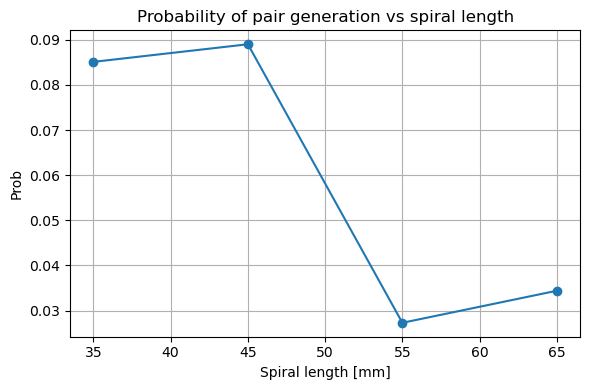

In [102]:
# plot probs
plt.figure(figsize=(6,4))
x = list(probs.keys())
y = list(probs.values())
plt.plot(x, y, 'o-')
plt.xlabel("Spiral length [mm]")
plt.ylabel("Prob")
plt.title("Probability of pair generation vs spiral length")
plt.grid()
plt.tight_layout()
plt.show()


In [141]:
count_rate_avg_35_c1 = np.mean(s1_35_trace['Count rate (counts/s), channel 1'])
count_rate_avg_35_c5 = np.mean(s1_35_trace['Count rate (counts/s), channel 5'])

count_rate_avg_45_c1 = np.mean(s2_45_trace['Count rate (counts/s), channel 1'])
count_rate_avg_45_c5 = np.mean(s2_45_trace['Count rate (counts/s), channel 5'])

count_rate_avg_55_c1 = np.mean(s3_55_trace['Count rate (counts/s), channel 1'])
count_rate_avg_55_c5 = np.mean(s3_55_trace['Count rate (counts/s), channel 5'])

count_rate_avg_65_c1 = np.mean(s4_65_trace['Count rate (counts/s), channel 1'])
count_rate_avg_65_c5 = np.mean(s4_65_trace['Count rate (counts/s), channel 5'])

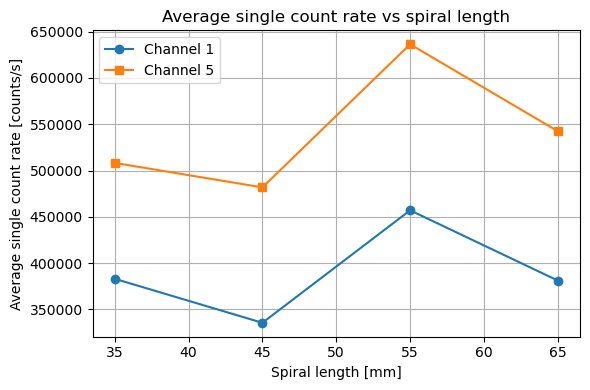

In [143]:
#plot count rates
plt.figure(figsize=(6,4))
x = [35, 45, 55, 65]
y_c1 = [count_rate_avg_35_c1, count_rate_avg_45_c1, count_rate_avg_55_c1, count_rate_avg_65_c1]
y_c5 = [count_rate_avg_35_c5, count_rate_avg_45_c5, count_rate_avg_55_c5, count_rate_avg_65_c5]
plt.plot(x, y_c1, 'o-', label="Channel 1")
plt.plot(x, y_c5, 's-', label="Channel 5")
plt.xlabel("Spiral length [mm]")
plt.ylabel("Average single count rate [counts/s]")
plt.title("Average single count rate vs spiral length")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()